## Level 2 – Task 1: Predicting House Prices with Linear Regression

### Objective
Build a Linear Regression model to predict house prices using different house features.


## 1. Import Libraries

I will use pandas for data handling, NumPy for calculations, matplotlib and seaborn for charts, and scikit-learn for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the Dataset

The CSV file is loaded into a DataFrame called `df`.

In [ ]:
df = pd.read_csv(r"enhanced_house_price_dataset.csv")

print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

df.head()

Dataset loaded successfully!
Rows and columns: (2000, 16)


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


## 3. Basic Information About the Dataset

Before analysis, I will check the column names, data types, missing values and duplicate rows.

In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

Column names:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price']

Data types:
Area                int64
Bedrooms            int64
Bathrooms           int64
Stories             int64
Parking             int64
Age                 int64
City                  str
Furnishing            str
Main Road             str
Guest Room            str
Basement              str
Water Supply          str
Air Conditioning      str
Preferred Tenant      str
Locality Rating     int64
Price               int64
dtype: object

Missing values:
Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality R

## 4. Descriptive Statistics

`describe()` gives a summary of the numerical columns, including count, mean, standard deviation, minimum, quartiles and maximum values.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,2000.0,3.238081e+03,1604.510239,401.0,1860.00,3271.5,4599.75,5996.0
Bedrooms,2000.0,3.031000e+00,1.427255,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.021500e+00,0.812630,1.0,1.00,2.0,3.00,3.0
Stories,2000.0,1.996000e+00,0.811981,1.0,1.00,2.0,3.00,3.0
Parking,2000.0,9.905000e-01,0.806682,0.0,0.00,1.0,2.00,2.0
Age,2000.0,2.400850e+01,14.319076,0.0,12.00,24.0,36.00,49.0
Locality Rating,2000.0,5.357500e+00,2.843015,1.0,3.00,5.0,8.00,10.0
Price,2000.0,1.245014e+06,300174.383545,334635.0,1035277.75,1246602.0,1453606.75,2225409.0


## 5. Distribution of House Prices

Since `Price` is the target variable, I will first look at how house prices are distributed.

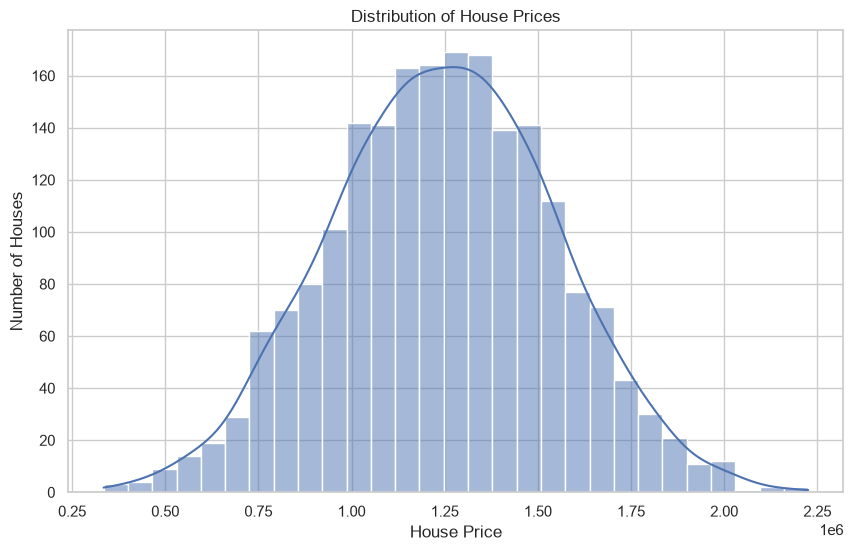

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Price"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.show()

## 6. Feature Selection Discussion

The target variable is `Price`. The remaining columns are possible predictors.

- **Area:** Larger houses may generally have higher prices.
- **Bedrooms:** More bedrooms may increase property value.
- **Bathrooms:** More bathrooms may increase desirability.
- **Stories:** The number of floors may be related to property size and value.
- **Parking:** Parking facilities can add value.
- **Age:** Age may affect price because properties can depreciate over time.
- **City:** Location is an important factor in real estate prices.
- **Furnishing:** Furnished properties may have different prices from unfurnished properties.
- **Main Road, Guest Room, Basement, Water Supply and Air Conditioning:** These property features may influence price.
- **Preferred Tenant:** This may have a smaller effect, but it is still a property-related categorical feature.
- **Locality Rating:** A better locality may be associated with a higher price.

I will use these available features first and then use correlation and model coefficients to understand their relationships with price.

## 7. Separate Features and Target

`Price` is the target because it is the value the model needs to predict. All other columns are features.

In [7]:
y = df["Price"]
X = df.drop("Price", axis=1)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant', 'Locality Rating']

Target:
Price


## 8. Identify Numerical and Categorical Columns

Numerical columns can be used as numbers. Categorical columns such as City and Furnishing need to be converted into numbers before training the model.

In [8]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(numerical_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

Numerical columns:
['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'Locality Rating']

Categorical columns:
['City', 'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply', 'Air Conditioning', 'Preferred Tenant']


C:\Users\HP\AppData\Local\Temp\ipykernel_21972\469726438.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


## 9. Handle Missing Values

The earlier check shows whether missing values exist. If there are missing values, numerical columns will use the median and categorical columns will use the most common value.

This dataset currently has no missing values, so these checks should not change the data.

In [9]:
for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

print("Total missing values after handling:")
print(df.isnull().sum().sum())

Total missing values after handling:
0


## 10. Convert Categorical Variables Into Numbers

Linear Regression works with numerical data, so categorical columns need to be converted.

I use pandas `get_dummies()` for One-Hot Encoding. `drop_first=True` removes one category from each categorical variable to avoid unnecessary redundant information.

In [10]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Shape after encoding:", df_encoded.shape)

df_encoded.head()

Shape after encoding: (2000, 24)


,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,City_Pune,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Main Road_Yes,Guest Room_Yes,Basement_Yes,Water Supply_Both,Water Supply_Corporation,Air Conditioning_Yes,Preferred Tenant_Company,Preferred Tenant_Family
0,1260,4,3,2,1,24,4,1274350,False,False,False,False,False,True,True,False,True,True,True,True,False,False,True,False
1,5790,2,1,1,1,7,5,1094846,False,False,False,True,False,False,False,True,True,True,True,True,False,True,False,False
2,5626,5,2,3,0,15,6,1495933,True,False,False,False,False,False,True,False,False,True,True,False,True,True,True,False
3,5591,1,1,1,1,47,3,1003442,False,True,False,False,False,False,False,False,True,False,True,False,False,False,True,False
4,4172,5,1,1,1,44,1,1306676,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False


## 11. Correlation With House Price

Correlation helps us see the strength and direction of a linear relationship between the variables and `Price`.

A value near +1 means a strong positive relationship, while a value near -1 means a strong negative relationship.

Correlation shows association, not causation.

In [11]:
correlation = df_encoded.corr(numeric_only=True)

price_correlation = correlation["Price"].sort_values(ascending=False)

print("Correlation with Price:")
display(price_correlation)

Correlation with Price:


Price                        1.000000
Bedrooms                     0.600588
Area                         0.339137
Bathrooms                    0.267506
Locality Rating              0.205792
Stories                      0.205615
Air Conditioning_Yes         0.186380
Parking                      0.159216
Guest Room_Yes               0.095375
Main Road_Yes                0.094667
Basement_Yes                 0.076522
Furnishing_Semi-Furnished    0.037231
Water Supply_Corporation     0.031587
City_Mumbai                  0.028225
City_Delhi                   0.017442
City_Kolkata                 0.009593
City_Hyderabad               0.001234
Preferred Tenant_Company    -0.002229
City_Pune                   -0.002261
Preferred Tenant_Family     -0.008706
Water Supply_Both           -0.035278
City_Chennai                -0.048470
Age                         -0.056614
Furnishing_Unfurnished      -0.214723
Name: Price, dtype: float64

## 12. Correlation Heatmap

The heatmap gives a visual summary of the correlations between the variables.

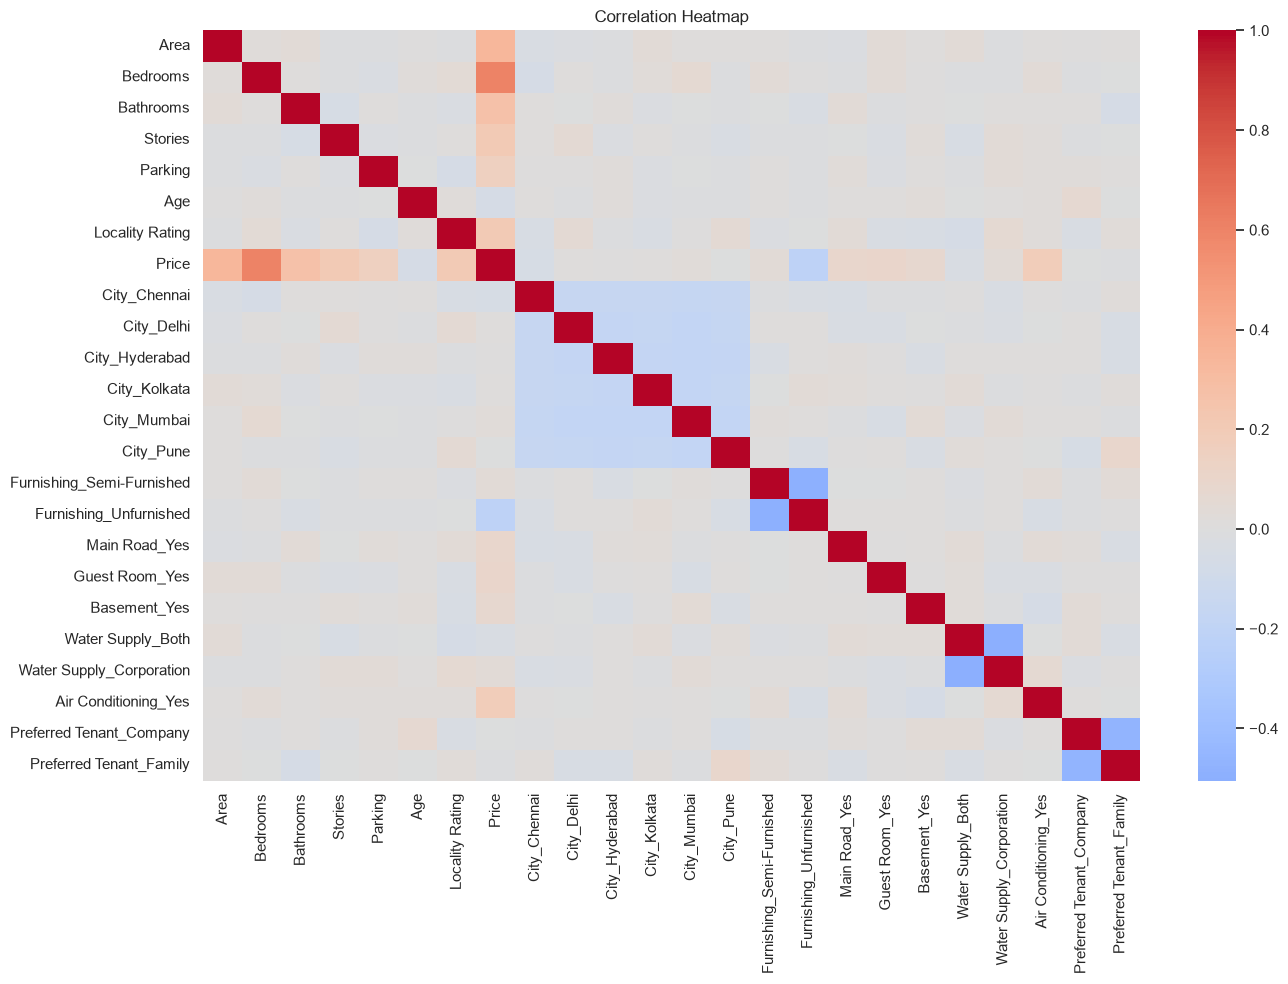

In [12]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 13. Prepare Data for Machine Learning

After encoding the categorical columns, I separate the encoded features and the target variable again.

In [13]:
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 23)
y shape: (2000,)


## 14. Train/Test Split – 80/20

I will use 80% of the data for training and 20% for testing.

The training data teaches the model, while the testing data checks how well the model performs on unseen data.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 23)
Testing data: (400, 23)


## 15. Train the Linear Regression Model

Linear Regression tries to learn a relationship between the house features and house price.

The model learns coefficients from the training data.

In [15]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 16. Make Predictions

The trained model is now used to predict prices for the test data.

In [16]:
y_pred = model.predict(X_test)

print("First 10 actual prices:")
print(y_test.head(10).values)

print("\nFirst 10 predicted prices:")
print(y_pred[:10])

First 10 actual prices:
[ 936067 1327841 1436138 1258537  886765 1358758 1322617 1076983  778863
 1687160]

First 10 predicted prices:
[ 986167.53350951 1380070.72253228 1377017.77253058  807907.19095857
 1000068.90008096 1129747.31678153 1390805.52019414 1265330.95499478
  767820.96428098 1661209.12095018]


## 17. Evaluate the Model

### MSE – Mean Squared Error
Measures the average squared prediction error. Lower is better.

### RMSE – Root Mean Squared Error
The square root of MSE. It is on the same general scale as the target price. Lower is better.

### R² – R-squared
Shows how much variation in house prices is explained by the model. Higher values are generally better.

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 20,133,032,720.03
Root Mean Squared Error (RMSE): 141,890.92
R² Score: 0.7779


## 18. Actual Price vs Predicted Price

This scatter plot compares actual prices with predicted prices.

The dashed diagonal line represents perfect predictions. The closer the points are to the line, the better the predictions.

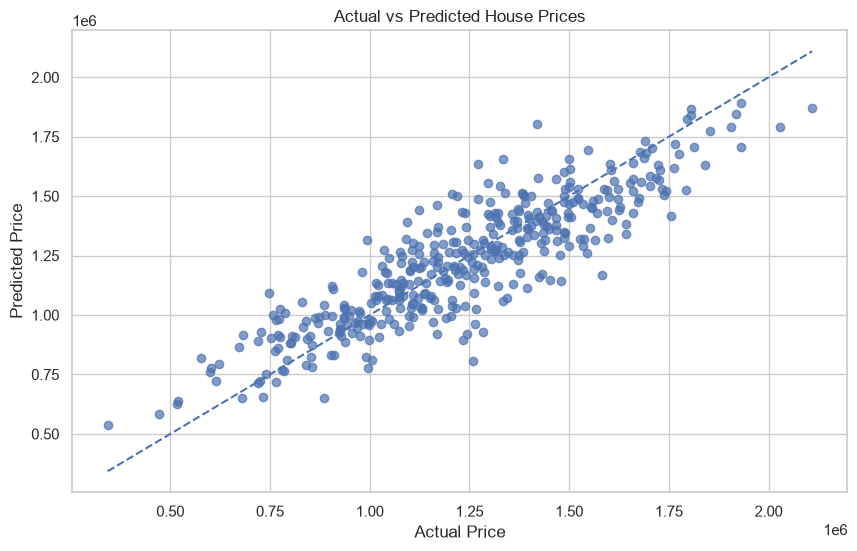

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## 19. Residual Analysis

A residual is the difference between actual and predicted price.

**Residual = Actual Price − Predicted Price**

Ideally, residuals should be scattered randomly around zero without a clear pattern.

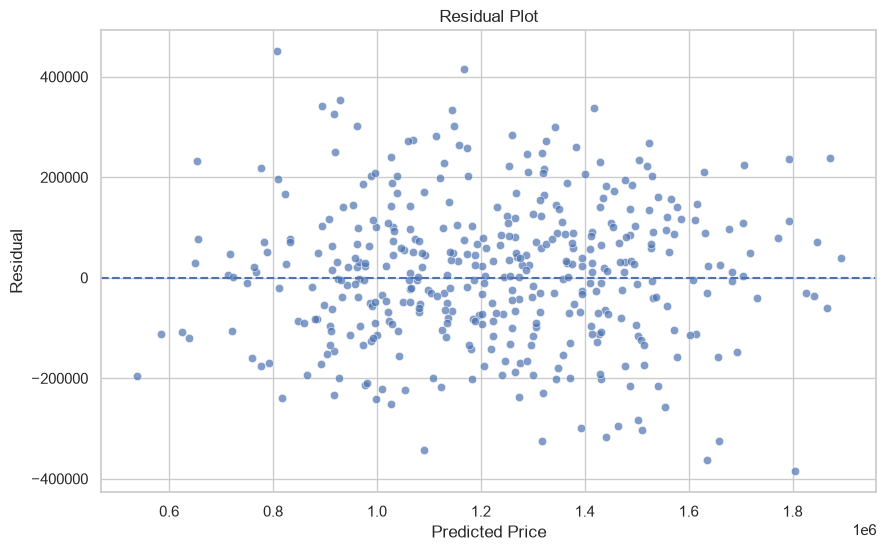

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.7
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

## 20. Analyze Model Coefficients

Linear Regression gives one coefficient to each feature.

- A positive coefficient means a positive relationship with predicted price, while other variables are held constant.
- A negative coefficient means a negative relationship.
- For one-hot encoded categories, the coefficient is interpreted relative to the category that was left out.

Because numerical features have different scales, coefficient sizes should be interpreted carefully.

In [20]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficient_table["Absolute Coefficient"] = coefficient_table["Coefficient"].abs()

coefficient_table = coefficient_table.sort_values(
    "Absolute Coefficient",
    ascending=False
)

print("Features with the largest absolute coefficients:")
display(coefficient_table.head(15))

Features with the largest absolute coefficients:


,Feature,Coefficient,Absolute Coefficient
14,Furnishing_Unfurnished,-164440.881906,164440.881906
1,Bedrooms,124147.976086,124147.976086
2,Bathrooms,91184.406752,91184.406752
20,Air Conditioning_Yes,90281.538453,90281.538453
3,Stories,84013.158222,84013.158222
13,Furnishing_Semi-Furnished,-80372.839984,80372.839984
4,Parking,69110.976595,69110.976595
15,Main Road_Yes,55432.069158,55432.069158
17,Basement_Yes,53941.414709,53941.414709
16,Guest Room_Yes,53354.271357,53354.271357


## 21. Highest Positive and Negative Coefficients

This helps identify features with the strongest positive and negative model coefficients.

In [21]:
print("Top positive coefficients:")
display(
    coefficient_table
    .sort_values("Coefficient", ascending=False)
    .head(10)[["Feature", "Coefficient"]]
)

print("Top negative coefficients:")
display(
    coefficient_table
    .sort_values("Coefficient", ascending=True)
    .head(10)[["Feature", "Coefficient"]]
)

Top positive coefficients:


,Feature,Coefficient
1,Bedrooms,124147.976086
2,Bathrooms,91184.406752
20,Air Conditioning_Yes,90281.538453
3,Stories,84013.158222
4,Parking,69110.976595
15,Main Road_Yes,55432.069158
17,Basement_Yes,53941.414709
16,Guest Room_Yes,53354.271357
6,Locality Rating,20277.055332
9,City_Hyderabad,9631.247998


Top negative coefficients:


,Feature,Coefficient
14,Furnishing_Unfurnished,-164440.881906
13,Furnishing_Semi-Furnished,-80372.839984
18,Water Supply_Both,-19706.008138
12,City_Pune,-12202.883518
19,Water Supply_Corporation,-4234.614001
8,City_Delhi,-4173.773328
21,Preferred Tenant_Company,-3447.515704
10,City_Kolkata,-2821.677261
5,Age,-1694.672386
0,Area,58.725517


## 22. Coefficient Visualization

The chart below shows the features with the largest absolute coefficients.

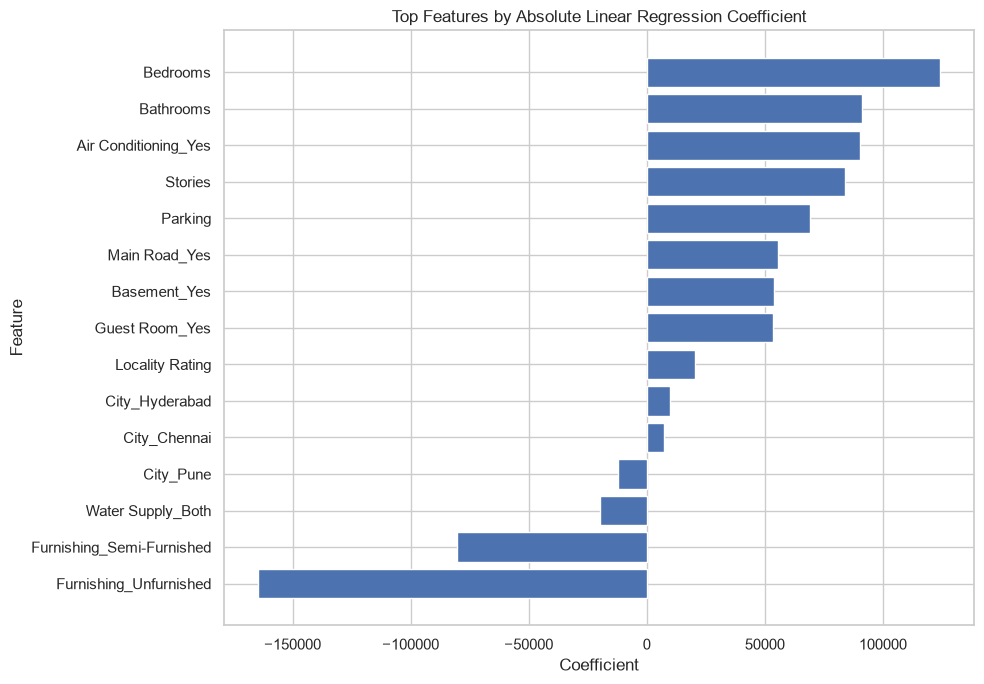

In [22]:
top_coefficients = coefficient_table.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 7))

plt.barh(
    top_coefficients["Feature"],
    top_coefficients["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features by Absolute Linear Regression Coefficient")
plt.tight_layout()
plt.show()

## 23. Conclusion

### What I learned from this project

- I explored the house price dataset and checked its quality.
- I identified possible factors that could influence house prices.
- I handled categorical variables using One-Hot Encoding.
- I split the data into training and testing sets using an 80/20 ratio.
- I trained a Linear Regression model to predict house prices.
- I evaluated the model using MSE, RMSE and R².
- I used actual-vs-predicted and residual plots to understand model performance.
- I examined model coefficients to understand feature impact.

### Business Insight

A house price prediction model can provide an estimated property value from available property characteristics. However, actual market prices can also depend on factors that are not present in the dataset, so predictions should be treated as estimates rather than exact prices.